# 01 — EDA и отбор признаков для модели дефицитных состояний

Этот ноутбук — первый этап новой ML-части проекта. Его задача — **не обучить финальную модель**, а понять данные и получить обоснованный набор признаков для следующих моделей.

Что делаем:
1. Загружаем исходный `deficiency_anemia.csv` и проверяем структуру.
2. Жёстко отделяем входные признаки от целевых столбцов, чтобы не допустить target leakage.
3. Проверяем правило определения анемии по полу и гемоглобину.
4. Анализируем баланс классов и решаем, нужно ли расширять датасет.
5. Анализируем пропуски и проверяем риск того, что модель учится по факту назначения анализа.
6. Выполняем базовую фильтрацию по дисперсии.
7. Применяем Kruskal–Wallis и оцениваем не только p-value, но и размер эффекта.
8. Кластеризуем **признаки** по корреляции Spearman с помощью иерархической кластеризации.
9. Проверяем стабильность отбора признаков через L1 Logistic Regression внутри cross-validation.
10. Получаем model-based permutation importance только на validation-folds.
11. Собираем единую таблицу, на основании которой будем строить L1 + CatBoost + rule-based ensemble.

> Важно: результаты отбора на полном датасете ниже используются только для EDA. При финальном сравнении моделей весь обучаемый preprocessing и feature selection должен выполняться **внутри train-fold**, иначе появится leakage из validation в обучение.

## 1. Импорты и воспроизводимость

Используем только стандартный стек `pandas / numpy / scipy / scikit-learn / matplotlib / seaborn`. `CatBoost` в этом ноутбуке специально не нужен: здесь мы исследуем данные и формируем кандидатов для следующего этапа.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import kruskal

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold

RANDOM_STATE = 42
N_SPLITS = 5
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Загрузка данных

По структуре проекта CSV лежит в `data/raw/deficiency_anemia.csv`, а ноутбук — в `notebooks/`. Код ниже работает и если Jupyter запущен из корня проекта, и если рабочая папка — `notebooks`.

Переменная окружения `DEFICIENCY_DATA_PATH` необязательна; она нужна только для запуска ноутбука на другом пути, не меняя код.

In [2]:
cwd = Path.cwd().resolve()
project_root = cwd.parent if cwd.name == "notebooks" else cwd

default_data_path = project_root / "data" / "raw" / "deficiency_anemia.csv"
data_path = Path(os.environ.get("DEFICIENCY_DATA_PATH", default_data_path)).expanduser().resolve()

print("Текущая рабочая папка:", cwd)
print("Корень проекта:", project_root)
print("Путь к данным:", data_path)
print("Файл существует:", data_path.exists())

if not data_path.exists():
    raise FileNotFoundError(
        f"Не найден {data_path}. Проверьте, что CSV лежит в data/raw/deficiency_anemia.csv"
    )

df = pd.read_csv(data_path)
print(f"Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
df.head()

Текущая рабочая папка: /home/sinopah/meditron/notebooks
Корень проекта: /home/sinopah/meditron
Путь к данным: /home/sinopah/meditron/data/raw/deficiency_anemia.csv
Файл существует: True
Размер датасета: 840 строк × 48 столбцов


,patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,WBC,reticulocytes,ferritin,serum_iron,transferrin,TIBC,UIBC,TSAT,sTfR,Ret_He,vitamin_B12,active_B12,MMA,homocysteine,folate,vitamin_B6,copper,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin,anemia,iron_deficiency,B12_deficiency,folate_deficiency,B6_deficiency,copper_deficiency,inflammation_anemia,mixed_deficiency,anemia_class,deficiency_cause
0,P000001,64,M,139.6,4.99,41.8,83.3,28.0,332.5,13.3,297,7.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.8,257.0,32.8,0.373,22.8,3.9,NaN,NaN,NaN,1.5,19.0,85.0,78.0,NaN,NaN,150.0,NaN,NaN,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
1,P000002,52,F,122.3,3.87,35.5,90.0,31.6,343.7,19.8,234,4.58,1.6,NaN,20.1,2.06,56.6,36.5,35.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2,NaN,65.0,114.0,8.46,NaN,NaN,NaN,NaN,0,0,0,1,0,0,0,0,folate_deficiency_no_anemia,folate_deficiency
2,P000003,43,F,144.9,5.20,44.6,86.1,27.9,329.2,14.7,288,8.31,NaN,37.6,8.0,3.06,80.5,72.5,9.9,5.3,25.9,579.0,90.1,0.153,NaN,NaN,56.1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87,0,1,0,0,0,0,0,0,latent_deficiency,iron_deficiency
3,P000004,26,F,121.7,4.46,39.0,86.9,27.3,316.2,16.7,386,5.79,NaN,107.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,14.2,NaN,31.7,NaN,NaN,NaN,NaN,NaN,3.0,66.0,110.0,1.87,NaN,NaN,NaN,NaN,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
4,P000005,30,F,111.5,2.98,32.5,109.1,37.5,341.6,19.7,281,6.36,NaN,150.2,NaN,NaN,NaN,NaN,NaN,NaN,31.5,157.0,NaN,0.447,NaN,6.7,NaN,NaN,NaN,1.0,NaN,78.0,108.0,2.54,43.2,500.0,29.9,NaN,1,0,1,0,0,0,0,0,B12_deficiency_anemia,B12_deficiency


## 3. Разделяем признаки и ответы — защита от target leakage

В файле 48 столбцов, но **не все они являются входными параметрами пациента**. Последние столбцы содержат уже готовые диагностические ответы. Если дать их модели как признаки, она фактически увидит правильный ответ во время обучения.

Поэтому исключаем:
- `patient_id` — идентификатор, а не медицинский признак;
- восемь бинарных целевых меток;
- `anemia_class`;
- `deficiency_cause`.

После этого должно остаться **37 потенциальных входных признаков**.

In [3]:
ID_COLUMN = "patient_id"
BINARY_TARGETS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
]
TARGET_COLUMNS = BINARY_TARGETS + ["anemia_class", "deficiency_cause"]
FEATURE_COLUMNS = [c for c in df.columns if c not in TARGET_COLUMNS + [ID_COLUMN]]

assert ID_COLUMN in df.columns
assert set(TARGET_COLUMNS).issubset(df.columns)
assert len(FEATURE_COLUMNS) == 37, f"Ожидалось 37 признаков, получено {len(FEATURE_COLUMNS)}"
assert not (set(FEATURE_COLUMNS) & set(TARGET_COLUMNS))

print("Целевых столбцов:", len(TARGET_COLUMNS))
print("Разрешённых входных признаков:", len(FEATURE_COLUMNS))
print(FEATURE_COLUMNS)

Целевых столбцов: 10
Разрешённых входных признаков: 37
['age_years', 'sex', 'hemoglobin', 'RBC', 'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW', 'platelets', 'WBC', 'reticulocytes', 'ferritin', 'serum_iron', 'transferrin', 'TIBC', 'UIBC', 'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'active_B12', 'MMA', 'homocysteine', 'folate', 'vitamin_B6', 'copper', 'ceruloplasmin', 'CRP', 'ESR', 'creatinine', 'eGFR', 'TSH', 'albumin', 'LDH', 'indirect_bilirubin', 'haptoglobin']


## 4. Базовая проверка качества

До статистики проверяем дубликаты, типы и уникальность пациентов. Это простой sanity check: ошибки здесь сделают бессмысленными все дальнейшие метрики.

In [4]:
quality_summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "unique_patient_id": df[ID_COLUMN].nunique(),
    "duplicate_patient_id": df[ID_COLUMN].duplicated().sum(),
    "duplicate_full_rows": df.duplicated().sum(),
})
display(quality_summary.to_frame("value"))
display(df[FEATURE_COLUMNS].dtypes.to_frame("dtype").T)

,value
rows,840
columns,48
unique_patient_id,840
duplicate_patient_id,0
duplicate_full_rows,0


,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,WBC,reticulocytes,ferritin,serum_iron,transferrin,TIBC,UIBC,TSAT,sTfR,Ret_He,vitamin_B12,active_B12,MMA,homocysteine,folate,vitamin_B6,copper,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin
dtype,int64,str,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


## 5. Первый уровень задачи: анемию определяем правилом, а не ML

По условию кейса наличие анемии определяется порогом гемоглобина:

- женщины (`F`): `hemoglobin < 120` г/л;
- мужчины (`M`): `hemoglobin < 130` г/л.

Если предоставленная метка `anemia` полностью воспроизводится этим правилом, обучать отдельную ML-модель для неё не нужно. ML будет решать более сложную задачу — **природу дефицита/анемии**.

In [5]:
valid_sex = df["sex"].isin(["F", "M"])
assert valid_sex.all(), f"Найдены неожиданные значения sex: {df.loc[~valid_sex, 'sex'].unique()}"

anemia_by_rule = np.where(
    df["sex"].eq("F"),
    df["hemoglobin"] < 120,
    df["hemoglobin"] < 130,
).astype(int)

rule_mismatches = int((anemia_by_rule != df["anemia"]).sum())
print(f"Несовпадений правила с меткой anemia: {rule_mismatches} из {len(df)}")

if rule_mismatches == 0:
    print("Вывод: anemia полностью воспроизводится правилом Hb + sex; отдельная ML-модель здесь не нужна.")
else:
    display(df.loc[anemia_by_rule != df["anemia"], ["sex", "hemoglobin", "anemia", "anemia_class"]])

Несовпадений правила с меткой anemia: 0 из 840
Вывод: anemia полностью воспроизводится правилом Hb + sex; отдельная ML-модель здесь не нужна.


## 6. Баланс классов и решение об увеличении датасета

Здесь отвечаем на вопрос: **нужно ли нам увеличивать датасет?**

Важно разделить две задачи:
1. Нужны ли дополнительные *здоровые негативные* примеры?
2. Нужны ли вообще дополнительные данные?

Совет ML-инженера — иметь примерно 10–20% условно здоровых примеров. В нашем датасете здоровый класс — `no_anemia_no_deficiency`. Сначала считаем его фактическую долю. Затем отдельно смотрим редкие классы и бинарные дефициты.

In [6]:
class_counts = df["anemia_class"].value_counts()
class_share = (df["anemia_class"].value_counts(normalize=True) * 100).round(1)
class_table = pd.DataFrame({"n": class_counts, "share_%": class_share})
display(class_table)

healthy_class = "no_anemia_no_deficiency"
healthy_n = int((df["anemia_class"] == healthy_class).sum())
healthy_share = healthy_n / len(df) * 100

binary_prevalence = pd.DataFrame({
    "positive_n": df[BINARY_TARGETS].sum().astype(int),
    "positive_%": (df[BINARY_TARGETS].mean() * 100).round(1),
}).sort_values("positive_n")

print(f"Условно здоровых: {healthy_n}/{len(df)} = {healthy_share:.1f}%")
display(binary_prevalence)

,n,share_%
anemia_class,,
iron_deficiency_anemia,115,13.7
mixed_deficiency,115,13.7
no_anemia_no_deficiency,110,13.1
latent_deficiency,85,10.1
anemia_other,75,8.9
B12_deficiency_anemia,65,7.7
inflammation_anemia,65,7.7
B12_deficiency_no_anemia,50,6.0
folate_deficiency_anemia,50,6.0


Условно здоровых: 110/840 = 13.1%


,positive_n,positive_%
copper_deficiency,35,4.2
B6_deficiency,35,4.2
inflammation_anemia,65,7.7
mixed_deficiency,115,13.7
folate_deficiency,155,18.5
B12_deficiency,190,22.6
iron_deficiency,290,34.5
anemia,531,63.2


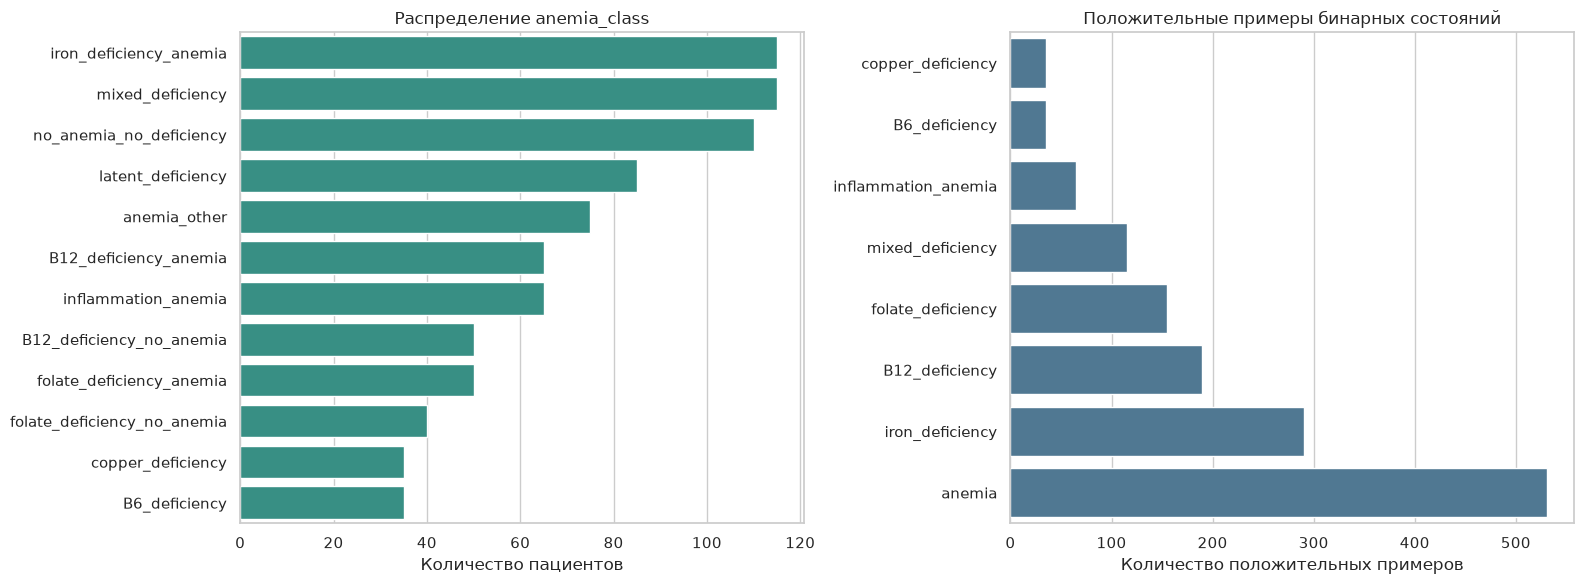

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x=class_table["n"].values,
    y=class_table.index,
    ax=axes[0],
    color="#2a9d8f",
)
axes[0].set_title("Распределение anemia_class")
axes[0].set_xlabel("Количество пациентов")
axes[0].set_ylabel("")

sns.barplot(
    x=binary_prevalence["positive_n"].values,
    y=binary_prevalence.index,
    ax=axes[1],
    color="#457b9d",
)
axes[1].set_title("Положительные примеры бинарных состояний")
axes[1].set_xlabel("Количество положительных примеров")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### Решение по увеличению датасета

Для предоставленного файла ожидаем около **13%** `no_anemia_no_deficiency`. Это уже попадает в рекомендуемые 10–20%, поэтому **искусственно добавлять здоровых только ради процента не нужно**.

Но общий объём 840 пациентов остаётся небольшим, а для `B6_deficiency` и `copper_deficiency` положительных примеров особенно мало. Поэтому расширение датасета нам полезно, но приоритет такой:

1. реальные дополнительные обезличенные данные по редким дефицитам и смешанным состояниям;
2. внешние данные (например, NHANES) только после гармонизации названий показателей, единиц измерения и правил формирования target;
3. `class_weight` как первый способ борьбы с дисбалансом;
4. SMOTE/другая синтетическая аугментация — только как отдельный эксперимент и **только внутри train-fold**, никогда не в validation/test.

Внешний источник нельзя просто `concat`-нуть с этим CSV: иначе модель может выучить различия лабораторий/источников вместо болезни. Для внешних данных нам понадобится отдельная проверка domain shift и source-aware validation.

## 7. Пропуски

В медицинских данных отсутствие анализа не обязательно случайно: врач мог назначить конкретный тест из-за подозрения на определённый дефицит. Поэтому `missing/not missing` потенциально само является признаком диагноза. Это удобно для метрики на исходном датасете, но опасно для переноса модели в реальный сервис.

In [8]:
missing_table = (
    pd.DataFrame({
        "missing_n": df[FEATURE_COLUMNS].isna().sum(),
        "missing_%": (df[FEATURE_COLUMNS].isna().mean() * 100).round(1),
        "n_unique": df[FEATURE_COLUMNS].nunique(dropna=True),
    })
    .sort_values("missing_%", ascending=False)
)
display(missing_table)

,missing_n,missing_%,n_unique
copper,716,85.2,89
ceruloplasmin,709,84.4,36
vitamin_B6,705,83.9,125
Ret_He,614,73.1,117
active_B12,588,70.0,227
sTfR,588,70.0,166
MMA,568,67.6,200
homocysteine,542,64.5,178
indirect_bilirubin,515,61.3,164
LDH,515,61.3,206


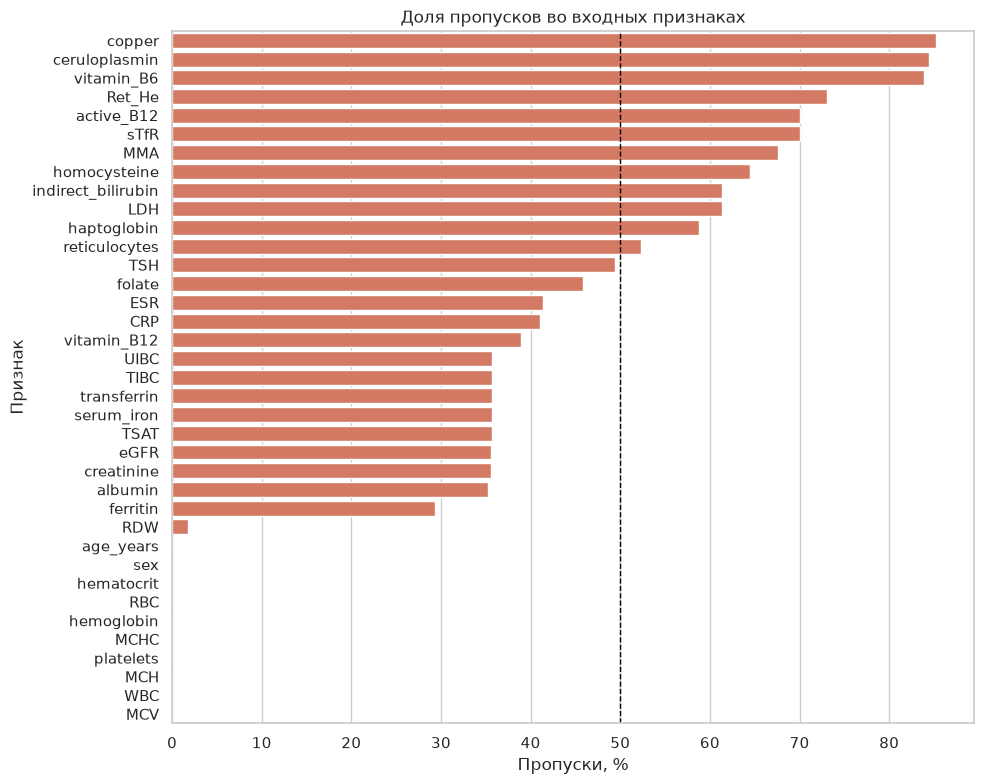

In [9]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=missing_table.reset_index(),
    x="missing_%",
    y="index",
    color="#e76f51",
)
plt.axvline(50, color="black", linestyle="--", linewidth=1)
plt.xlabel("Пропуски, %")
plt.ylabel("Признак")
plt.title("Доля пропусков во входных признаках")
plt.tight_layout()
plt.show()

### 7.1. Зависит ли факт назначения анализа от класса?

Для каждого признака сравниваем долю пропусков между 12 классами. Большой `missingness_spread` означает, что в одном классе анализ назначался намного чаще, чем в другом. Это сигнал возможного shortcut.

In [10]:
numeric_features = df[FEATURE_COLUMNS].select_dtypes(include=np.number).columns.tolist()

missing_by_class = df.groupby("anemia_class")[numeric_features].agg(lambda s: s.isna().mean())
missingness_spread = ((missing_by_class.max() - missing_by_class.min()) * 100).sort_values(ascending=False)

missingness_risk = pd.DataFrame({
    "overall_missing_%": (df[numeric_features].isna().mean() * 100).round(1),
    "between_class_spread_pp": missingness_spread.round(1),
}).sort_values("between_class_spread_pp", ascending=False)
display(missingness_risk.head(20))

,overall_missing_%,between_class_spread_pp
copper,85.2,81.7
vitamin_B6,83.9,75.2
ceruloplasmin,84.4,74.6
haptoglobin,58.8,62.5
vitamin_B12,38.9,62.5
LDH,61.3,59.6
ferritin,29.3,54.1
serum_iron,35.7,50.6
UIBC,35.7,50.6
transferrin,35.7,50.6


### 7.2. Диагностический тест: можно ли угадывать класс только по пропускам?

Это **не кандидат на финальную модель**. Напротив, специально обучаем небольшой Random Forest только на бинарной матрице `isna()`. Если он заметно лучше `DummyClassifier`, значит паттерн назначения анализов содержит информацию о диагнозе и мы обязаны учитывать это при проверке устойчивости финальной модели.

In [11]:
X_missing = df[numeric_features].isna().astype("int8")
y_class = df["anemia_class"]
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

missingness_scores = []
for fold, (train_idx, valid_idx) in enumerate(cv.split(X_missing, y_class), start=1):
    X_train, X_valid = X_missing.iloc[train_idx], X_missing.iloc[valid_idx]
    y_train, y_valid = y_class.iloc[train_idx], y_class.iloc[valid_idx]

    models = {
        "dummy": DummyClassifier(strategy="prior"),
        "missingness_only_rf": RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
        ),
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)
        missingness_scores.append({
            "fold": fold,
            "model": name,
            "macro_f1": f1_score(y_valid, pred, average="macro"),
            "accuracy": accuracy_score(y_valid, pred),
        })

missingness_scores = pd.DataFrame(missingness_scores)
display(missingness_scores.groupby("model")[["macro_f1", "accuracy"]].agg(["mean", "std"]).round(3))

macro_f1        accuracy       
                        mean    std     mean    std
model                                              
dummy                  0.020  0.000    0.137  0.000
missingness_only_rf    0.238  0.016    0.267  0.014

**Как интерпретируем:** если `missingness_only_rf` заметно **сильнее** `dummy`, отсутствие анализа нельзя считать безобидным. Для финальной системы сравним модель, которая может использовать missingness, с моделью, где эта информация максимально нейтрализована. Хорошая метрика только за счёт паттерна назначения анализов будет считаться ненадёжной.

## 8. Фильтрация по дисперсии

`VarianceThreshold` полезен прежде всего для удаления константных/почти константных технических признаков. Нельзя ставить один большой порог на **сырые** лабораторные показатели: у гемоглобина, CRP и альбумина разные единицы измерения и масштабы.

Поэтому здесь делаем безопасную проверку `threshold=0`: удаляем только признаки, у которых после медианной импутации вообще нет вариации. Более агрессивное уменьшение размерности выполняем через Kruskal, корреляционные кластеры и L1.

In [12]:
numeric_imputed = SimpleImputer(strategy="median").fit_transform(df[numeric_features])
variance_filter = VarianceThreshold(threshold=0.0)
variance_filter.fit(numeric_imputed)

constant_features = [
    feature
    for feature, keep in zip(numeric_features, variance_filter.get_support())
    if not keep
]
print("Константные числовые признаки:", constant_features if constant_features else "не найдены")

Константные числовые признаки: не найдены


## 9. Kruskal–Wallis: различаются ли значения признака между классами?

Kruskal–Wallis — непараметрический тест, поэтому он хорошо подходит как EDA-фильтр для лабораторных показателей, распределения которых часто не нормальны.

Но одного `p-value` недостаточно: при разных объёмах данных он плохо показывает практическую силу связи. Поэтому дополнительно считаем приближённый размер эффекта `epsilon²`.

Для множества тестов применяем Benjamini–Hochberg FDR correction. Рейтинг на всём датасете здесь **исследовательский**; в финальном ML-пайплайне отбор должен обучаться только на train-fold.

In [13]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = ranked * n / np.arange(1, n + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted = np.empty(n, dtype=float)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted


def kruskal_feature_table(data, features, target):
    rows = []
    for feature in features:
        groups = [
            group[feature].dropna().to_numpy()
            for _, group in data.groupby(target)
            if group[feature].notna().sum() >= 2
        ]
        if len(groups) < 2:
            continue

        h_stat, p_value = kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)
        epsilon2 = max(0.0, (h_stat - k + 1) / (n - k)) if n > k else np.nan

        rows.append({
            "feature": feature,
            "H": h_stat,
            "p_value": p_value,
            "epsilon2": epsilon2,
            "observed_n": data[feature].notna().sum(),
            "missing_%": data[feature].isna().mean() * 100,
        })

    result = pd.DataFrame(rows)
    result["p_fdr"] = benjamini_hochberg(result["p_value"].to_numpy())
    return result.sort_values(["epsilon2", "p_fdr"], ascending=[False, True]).reset_index(drop=True)


kw_table = kruskal_feature_table(df, numeric_features, "anemia_class")
display(kw_table.round({"H": 2, "epsilon2": 3, "missing_%": 1}).head(25))

,feature,H,p_value,epsilon2,observed_n,missing_%,p_fdr
0,homocysteine,226.77,1.999815e-42,0.754,298,64.5,5.142382e-42
1,hemoglobin,578.16,6.561921e-117,0.685,840,0.0,2.362292e-115
2,ferritin,408.90,7.890134e-81,0.684,594,29.3,4.057783e-80
3,TSAT,370.43,1.143527e-72,0.681,540,35.7,5.145874e-72
4,Ret_He,155.60,1.066510e-27,0.676,226,73.1,1.754610e-27
5,UIBC,358.65,3.577688e-70,0.658,540,35.7,1.431075e-69
6,hematocrit,550.54,5.239792e-111,0.652,840,0.0,9.431625e-110
7,serum_iron,353.97,3.493941e-69,0.650,540,35.7,1.257819e-68
8,RBC,530.16,1.174783e-106,0.627,840,0.0,1.409739e-105
9,sTfR,160.23,1.201672e-28,0.622,252,70.0,2.276852e-28


### Почему не берём просто глобальные TOP-3

Высокий Kruskal effect может быть у признака, который хорошо отделяет один частый класс, но бесполезен для редкого дефицита. Кроме того, очень сильный показатель может быть измерен лишь у небольшой части пациентов. Поэтому top-2/3 разумнее рассматривать **внутри клинических веток и корреляционных кластеров**, а не оставлять три признака на всю задачу.

## 10. Корреляции и иерархическая кластеризация признаков

Теперь транспонировать сам DataFrame буквально не требуется: для кластеризации признаков строим матрицу `feature × feature`. Используем абсолютную корреляцию Spearman, поскольку зависимости могут быть монотонными, но не линейными.

Расстояние между признаками:

`distance = 1 - |Spearman rho|`

Для correlation distance используем `average linkage`. Признаки с `|rho|` около 0.75 и выше будут считаться близкими.

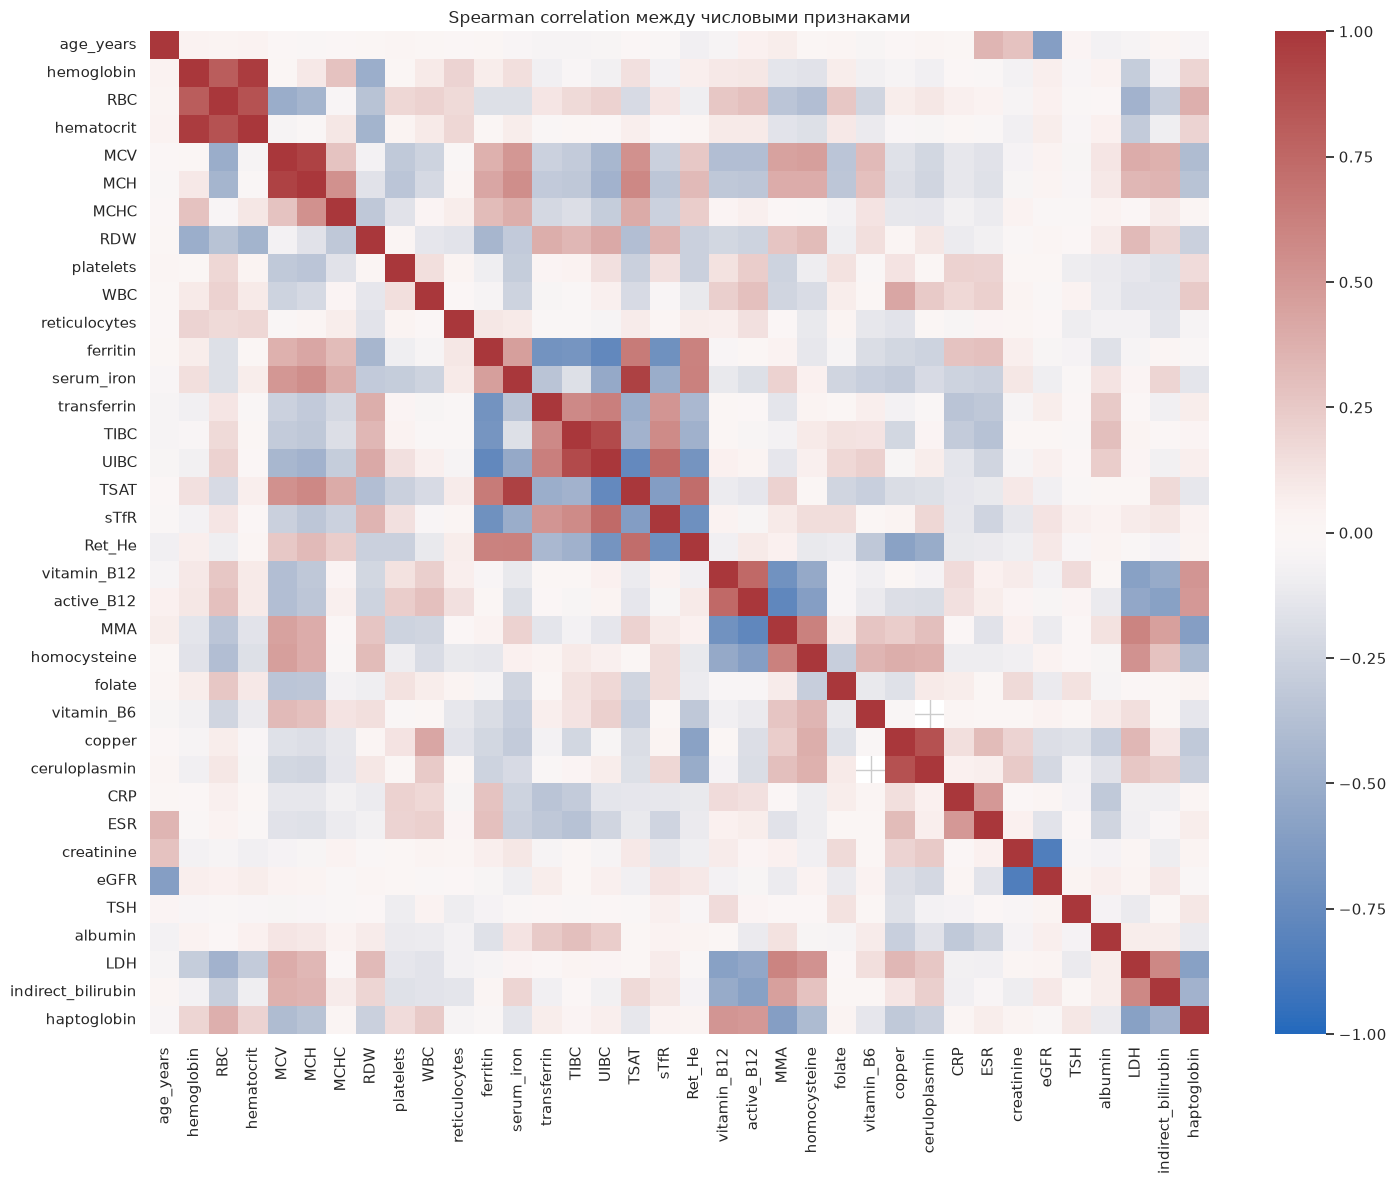

In [14]:
spearman_corr = df[numeric_features].corr(method="spearman", min_periods=20)

plt.figure(figsize=(15, 12))
sns.heatmap(spearman_corr, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation между числовыми признаками")
plt.tight_layout()
plt.show()

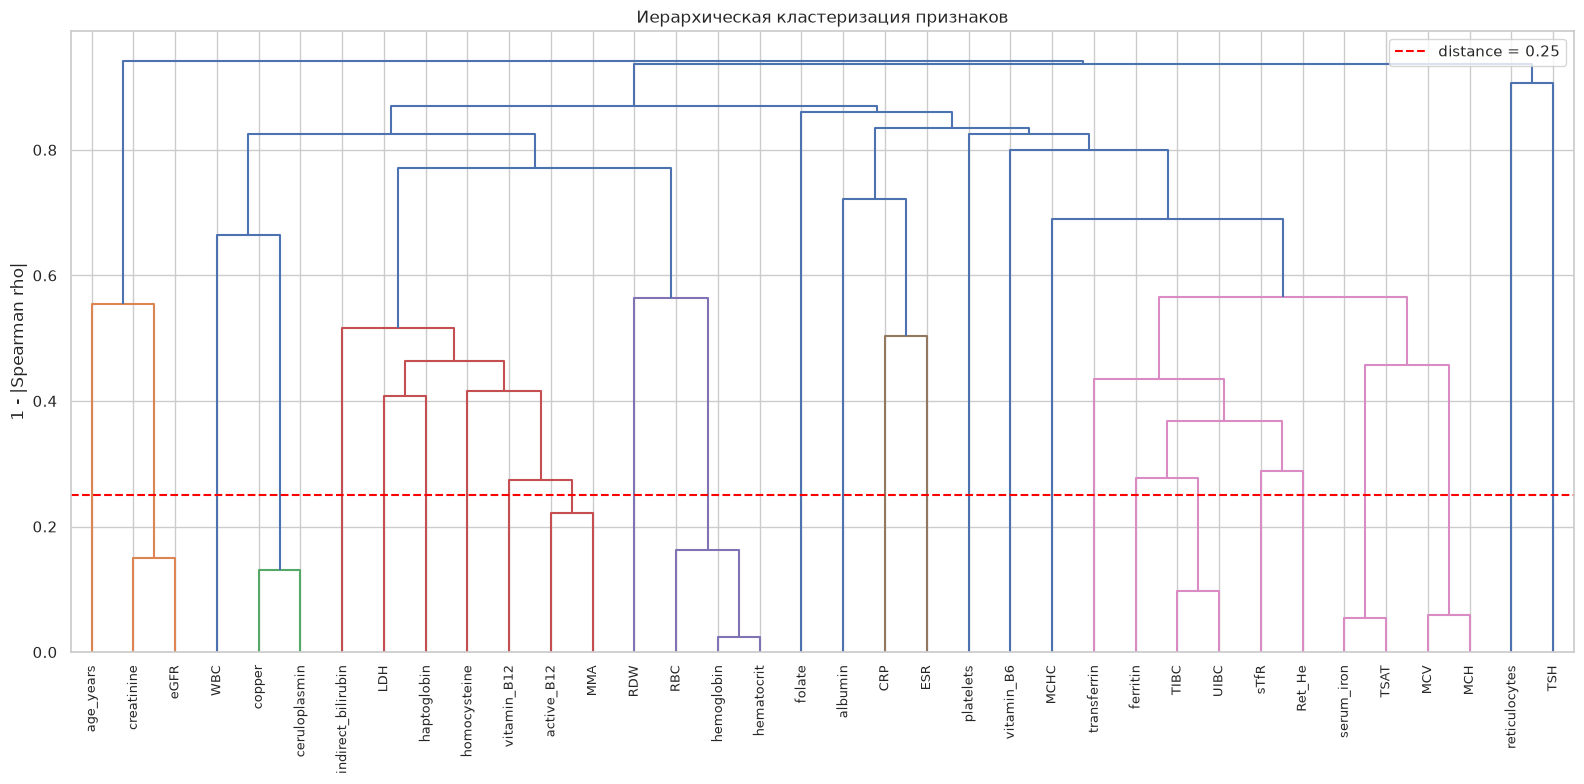

In [15]:
# Берём абсолютные значения корреляций
abs_corr = spearman_corr.abs().fillna(0.0).copy()

# Заполняем диагональ единицами через pandas,
# чтобы избежать ошибки "underlying array is read-only"
for i in range(len(abs_corr)):
    abs_corr.iat[i, i] = 1.0

# Преобразуем корреляцию в расстояние
distance_matrix = (1.0 - abs_corr).clip(0.0, 1.0)

# На всякий случай обеспечиваем симметричность
distance_matrix = (distance_matrix + distance_matrix.T) / 2

# Расстояние признака до самого себя = 0
for i in range(len(distance_matrix)):
    distance_matrix.iat[i, i] = 0.0

# Преобразуем квадратную матрицу расстояний
# в формат, необходимый scipy
condensed_distance = squareform(
    distance_matrix.to_numpy(copy=True),
    checks=True
)

# Иерархическая кластеризация
linkage_matrix = linkage(
    condensed_distance,
    method="average"
)

# Дендрограмма
plt.figure(figsize=(16, 8))

dendrogram(
    linkage_matrix,
    labels=numeric_features,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.axhline(
    0.25,
    color="red",
    linestyle="--",
    label="distance = 0.25"
)

plt.ylabel("1 - |Spearman rho|")
plt.title("Иерархическая кластеризация признаков")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
cluster_labels = fcluster(
    linkage_matrix,
    t=0.25,
    criterion="distance"
)

feature_clusters = pd.DataFrame({
    "feature": numeric_features,
    "cluster": cluster_labels,
})

feature_clusters = feature_clusters.merge(
    kw_table[["feature", "epsilon2", "p_fdr", "missing_%"]],
    on="feature",
    how="left",
)

feature_clusters = feature_clusters.sort_values(
    ["cluster", "epsilon2"],
    ascending=[True, False]
)

display(
    feature_clusters.round({
        "epsilon2": 3,
        "missing_%": 1
    })
)

,feature,cluster,epsilon2,p_fdr,missing_%
29,creatinine,1,0.124,7.995966e-12,35.6
30,eGFR,1,0.107,4.232019e-10,35.6
0,age_years,2,0.000,8.450022e-01,0.0
25,copper,3,0.585,8.158808e-12,85.2
26,ceruloplasmin,3,0.448,9.299257e-10,84.4
9,WBC,4,0.193,1.930723e-30,0.0
33,LDH,5,0.448,1.307343e-26,61.3
35,haptoglobin,6,0.434,1.726016e-27,58.8
20,active_B12,7,0.588,8.647515e-27,70.0
21,MMA,7,0.585,6.293425e-29,67.6


### Кандидат-представитель каждого корреляционного кластера

Код ниже выбирает **кандидата**, а не окончательно удаляет остальные признаки. При выборе учитываем сначала силу связи с классом, затем пропуски. Медицински важный маркер редкого состояния нельзя выбросить только потому, что его редко назначали. Окончательное решение примем после L1, permutation importance и анализа по отдельным дефицитам.

In [17]:
cluster_candidates = (
    feature_clusters
    .sort_values(["cluster", "epsilon2", "missing_%"], ascending=[True, False, True])
    .groupby("cluster", as_index=False)
    .first()
    .sort_values("epsilon2", ascending=False)
)
display(cluster_candidates.round({"epsilon2": 3, "missing_%": 1}))

,cluster,feature,epsilon2,p_fdr,missing_%
8,9,homocysteine,0.754,5.142382e-42,64.5
10,11,hemoglobin,0.685,2.362292e-115,0.0
16,17,ferritin,0.684,4.057783e-80,29.3
20,21,TSAT,0.681,5.145874e-72,35.7
18,19,Ret_He,0.676,1.754610e-27,73.1
15,16,UIBC,0.658,1.431075e-69,35.7
17,18,sTfR,0.622,2.276852e-28,70.0
6,7,active_B12,0.588,8.647515e-27,70.0
2,3,copper,0.585,8.158808e-12,85.2
11,12,RDW,0.563,1.366749e-92,1.8


## 11. L1 Logistic Regression: стабильный ли признак между folds?

L1-регуляризация умеет занулять коэффициенты и поэтому выступает одновременно моделью и методом feature selection. Но один fit нестабилен на маленьком датасете.

Поэтому:
- делим данные на 5 stratified folds;
- imputer и scaler обучаются только на train-fold;
- `C` выбирается внутренней 3-fold CV;
- фиксируем, в какой доле внешних folds признак получил хотя бы один ненулевой коэффициент.

Это ещё не финальная оценка модели — нас сейчас интересует **стабильность отбора признаков**.

In [18]:
X = df[FEATURE_COLUMNS].copy()
y = df["anemia_class"].copy()

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
        ]), categorical_cols),
    ],
    verbose_feature_names_out=False,
)

outer_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
l1_rows = []

for fold, (train_idx, valid_idx) in enumerate(outer_cv.split(X, y), start=1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    X_train_t = preprocessor.fit_transform(X_train)
    X_valid_t = preprocessor.transform(X_valid)
    transformed_names = preprocessor.get_feature_names_out()

    l1_model = LogisticRegressionCV(
        Cs=np.logspace(-2, 1, 6),
        cv=3,
        penalty="l1",
        solver="saga",
        scoring="f1_macro",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE + fold,
        refit=True,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        l1_model.fit(X_train_t, y_train)

    pred = l1_model.predict(X_valid_t)
    fold_f1 = f1_score(y_valid, pred, average="macro")
    nonzero = (np.abs(l1_model.coef_) > 1e-10).any(axis=0)

    for name, selected in zip(transformed_names, nonzero):
        l1_rows.append({
            "fold": fold,
            "feature": name,
            "selected": int(selected),
            "fold_macro_f1": fold_f1,
        })

l1_results = pd.DataFrame(l1_rows)
l1_stability = (
    l1_results.groupby("feature")
    .agg(l1_selected_folds=("selected", "sum"), l1_stability=("selected", "mean"))
    .sort_values(["l1_stability", "l1_selected_folds"], ascending=False)
)

print("Macro-F1 L1 по folds:")
display(l1_results.groupby("fold")["fold_macro_f1"].first().to_frame().round(3))
print("Стабильность ненулевых L1-коэффициентов:")
display(l1_stability)

Macro-F1 L1 по folds:


,fold_macro_f1
fold,
1,0.919
2,0.837
3,0.854
4,0.874
5,0.836


Стабильность ненулевых L1-коэффициентов:


,l1_selected_folds,l1_stability
feature,,
CRP,5,1.0
ESR,5,1.0
LDH,5,1.0
MCH,5,1.0
MCHC,5,1.0
MCV,5,1.0
MMA,5,1.0
RBC,5,1.0
RDW,5,1.0


## 12. Feature Importance — только на validation-folds

Чтобы выполнить ещё одну независимую проверку, обучаем Random Forest на каждом train-fold и считаем **permutation importance на соответствующем validation-fold**.

Почему не берём просто `model.feature_importances_`? Встроенная impurity importance может отдавать предпочтение признакам с определёнными свойствами. Permutation importance отвечает более прямому вопросу: *насколько ухудшается validation macro-F1, если перемешать этот признак?*

Random Forest здесь — диагностический инструмент для отбора признаков, а не утверждение, что это будет финальная модель.

In [19]:
X_numeric = df[numeric_features].copy()
perm_rows = []
perm_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for fold, (train_idx, valid_idx) in enumerate(perm_cv.split(X_numeric, y), start=1):
    X_train, X_valid = X_numeric.iloc[train_idx], X_numeric.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    imputer = SimpleImputer(strategy="median")
    X_train_i = pd.DataFrame(imputer.fit_transform(X_train), columns=numeric_features, index=X_train.index)
    X_valid_i = pd.DataFrame(imputer.transform(X_valid), columns=numeric_features, index=X_valid.index)

    rf = RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )
    rf.fit(X_train_i, y_train)

    perm = permutation_importance(
        rf,
        X_valid_i,
        y_valid,
        scoring="f1_macro",
        n_repeats=5,
        random_state=RANDOM_STATE + fold,
        n_jobs=-1,
    )

    for feature, importance in zip(numeric_features, perm.importances_mean):
        perm_rows.append({"fold": fold, "feature": feature, "perm_importance": importance})

perm_results = pd.DataFrame(perm_rows)
perm_summary = (
    perm_results.groupby("feature")["perm_importance"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "perm_importance_mean", "std": "perm_importance_std"})
    .sort_values("perm_importance_mean", ascending=False)
)
display(perm_summary.head(25).round(4))

,perm_importance_mean,perm_importance_std
feature,,
hemoglobin,0.1023,0.0190
vitamin_B6,0.0737,0.0031
folate,0.0696,0.0175
vitamin_B12,0.0560,0.0154
copper,0.0384,0.0092
ferritin,0.0374,0.0087
MCV,0.0166,0.0080
homocysteine,0.0153,0.0105
ceruloplasmin,0.0122,0.0063


## 13. Итоговая таблица evidence по признакам

Теперь соединяем четыре независимых источника информации:

- `missing_%` — насколько часто признак вообще доступен;
- `epsilon2 / p_fdr` — Kruskal–Wallis;
- `cluster` — группа сильно связанных признаков;
- `l1_stability` — как часто L1 сохраняет признак на разных folds;
- `perm_importance_mean` — validation permutation importance.

Эта таблица важнее любого одного TOP-N рейтинга.

In [20]:
feature_evidence = (
    kw_table[["feature", "epsilon2", "p_fdr", "observed_n", "missing_%"]]
    .merge(feature_clusters[["feature", "cluster"]], on="feature", how="left")
    .merge(l1_stability.reset_index(), on="feature", how="left")
    .merge(perm_summary.reset_index(), on="feature", how="left")
)

feature_evidence["l1_stability"] = feature_evidence["l1_stability"].fillna(0.0)
feature_evidence["l1_selected_folds"] = feature_evidence["l1_selected_folds"].fillna(0).astype(int)
feature_evidence = feature_evidence.sort_values(
    ["l1_stability", "epsilon2", "perm_importance_mean"],
    ascending=[False, False, False],
)

display(feature_evidence.round({
    "epsilon2": 3,
    "p_fdr": 5,
    "missing_%": 1,
    "l1_stability": 2,
    "perm_importance_mean": 4,
    "perm_importance_std": 4,
}))

,feature,epsilon2,p_fdr,observed_n,missing_%,cluster,l1_selected_folds,l1_stability,perm_importance_mean,perm_importance_std
0,homocysteine,0.754,0.00000,298,64.5,9,5,1.0,0.0153,0.0105
1,hemoglobin,0.685,0.00000,840,0.0,11,5,1.0,0.1023,0.0190
2,ferritin,0.684,0.00000,594,29.3,17,5,1.0,0.0374,0.0087
3,TSAT,0.681,0.00000,540,35.7,21,5,1.0,0.0115,0.0113
4,Ret_He,0.676,0.00000,226,73.1,19,5,1.0,-0.0000,0.0000
5,UIBC,0.658,0.00000,540,35.7,16,5,1.0,0.0106,0.0085
6,hematocrit,0.652,0.00000,840,0.0,11,5,1.0,0.0001,0.0129
7,serum_iron,0.650,0.00000,540,35.7,21,5,1.0,0.0065,0.0030
8,RBC,0.627,0.00000,840,0.0,11,5,1.0,-0.0002,0.0078
9,sTfR,0.622,0.00000,252,70.0,18,5,1.0,0.0015,0.0027


## 14. Что мы решаем после этого ноутбука

Мы **не будем** автоматически брать первые три строки `feature_evidence`. Вместо этого сформируем компактные диагностические панели и проверим их отдельно:

- **Iron:** ferritin, TSAT/serum_iron, sTfR/Ret_He и связанные показатели — окончательный состав по evidence.
- **B12:** vitamin_B12, active_B12/MMA, homocysteine.
- **Folate:** folate и связанные метаболические маркеры.
- **B6:** vitamin_B6 и подтверждающие доступные признаки.
- **Copper:** copper, ceruloplasmin и подтверждающие признаки.
- **Inflammation:** CRP, ESR, ferritin и связанные показатели.

Особенно осторожно относимся к признакам с 60–85% пропусков: высокий статистический эффект у них не означает, что они должны быть обязательны для каждого пациента.

### Следующий этап проекта

1. Зафиксировать компактный feature set на основании этого EDA.
2. Построить baseline direct 12-class L1 Logistic Regression.
3. Построить baseline CatBoost.
4. Перейти к основной иерархической схеме: `anemia` по правилу, отдельные вероятности дефицитов, затем сборка `anemia_class`/`deficiency_cause`.
5. Добавить rule-based слой с клинически подтверждёнными порогами.
6. Получать только out-of-fold метрики и калибровать вероятности.
7. Объединить L1 + CatBoost + rules в взвешенный ансамбль.
8. Отдельно проверить качество на пациентах с неполным набором анализов и при переносе на внешний источник.

**Главный принцип:** сначала доказываем, что признаки и validation честные, и только потом усложняем модель.